# Acoustics Homework #3 
### Due April 1, 2026
### Caleb Young
Note: I did this on paper and I transfered it to this notebook for ease in combining it with the plots needed. 

## Problem 1 

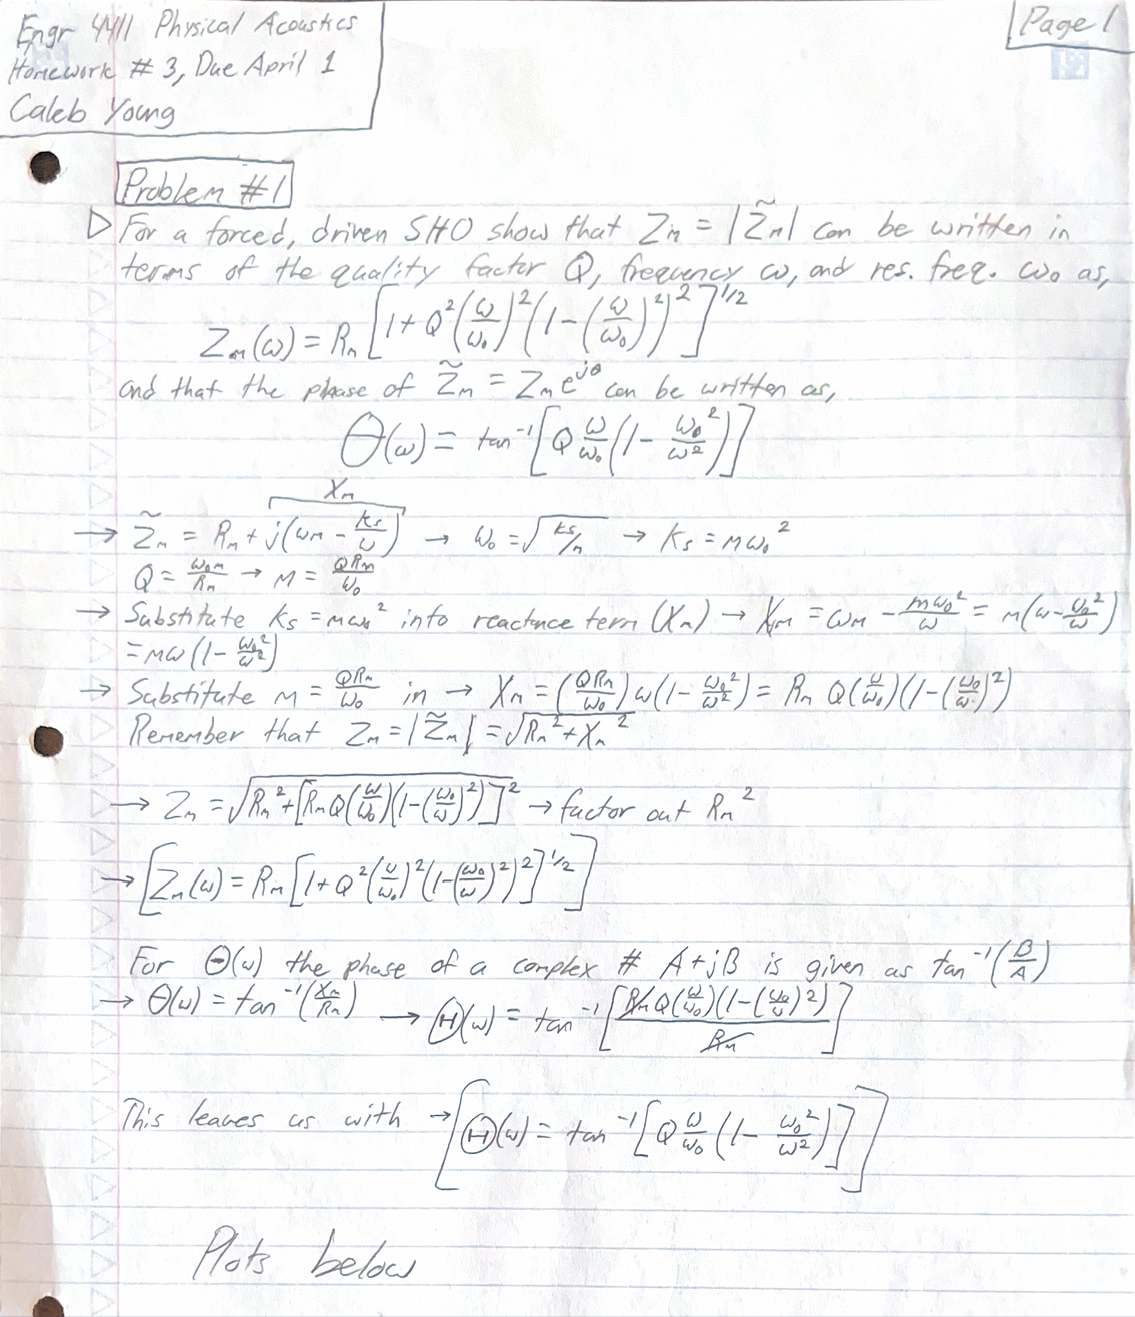

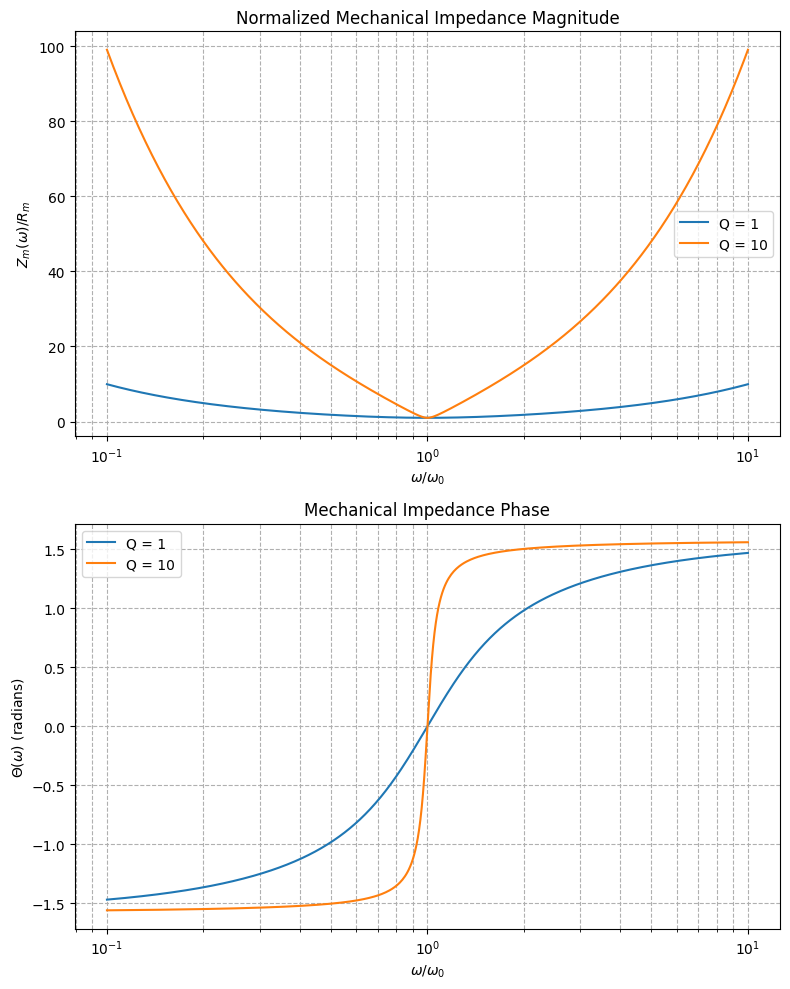

In [2]:
# Plots for Problem 1

import numpy as np
import matplotlib.pyplot as plt

# Define the range for w_ratio (which is w/w0)
w_ratio = np.logspace(-1, 1, 500) # 0.1 to 10 on a log scale for better visualization

# Define the Q values
Q_values = [1, 10]

# Setup the figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))

for Q in Q_values:
    # Normalized Magnitude: Z_m / R_m
    Z_norm = np.sqrt(1 + (Q**2) * (w_ratio**2) * (1 - (1 / w_ratio)**2)**2)
    
    # Phase in radians
    Phase_rad = np.arctan(Q * w_ratio * (1 - (1 / w_ratio)**2))
    
    # Plotting
    ax1.semilogx(w_ratio, Z_norm, label=f'Q = {Q}')
    ax2.semilogx(w_ratio, Phase_rad, label=f'Q = {Q}')

# Format Magnitude Plot
ax1.set_title('Normalized Mechanical Impedance Magnitude')
ax1.set_ylabel(r'$Z_m(\omega) / R_m$')
ax1.set_xlabel(r'$\omega / \omega_0$')
ax1.grid(True, which="both", ls="--")
ax1.legend()

# Format Phase Plot
ax2.set_title('Mechanical Impedance Phase')
ax2.set_ylabel(r'$\Theta(\omega)$ (radians)')
ax2.set_xlabel(r'$\omega / \omega_0$')
ax2.grid(True, which="both", ls="--")
ax2.legend()

plt.tight_layout()
plt.show()

## Problem 2 

This one is mainly just plots. My plot of a waveform that moves right with a constant speed without changing shape is down below. 

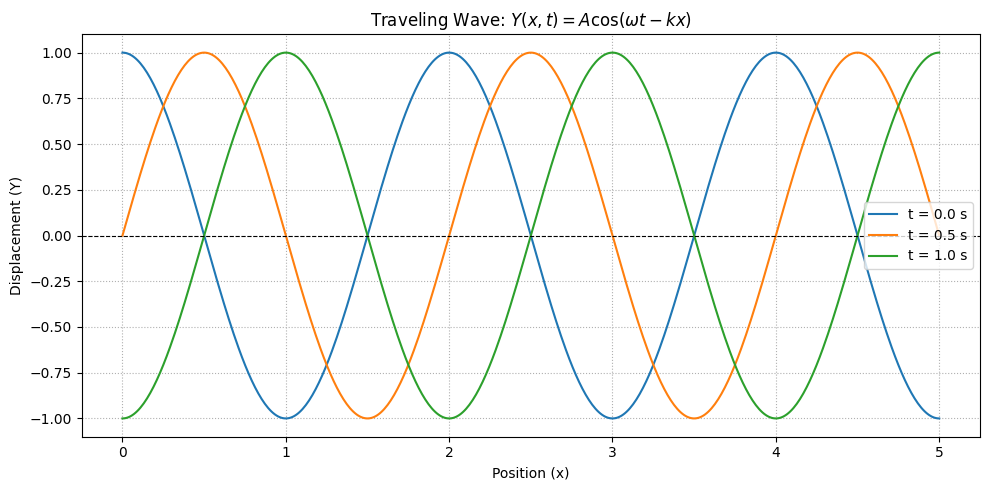

In [3]:
# Plots for Problem 2

import numpy as np
import matplotlib.pyplot as plt

# Define wave parameters
A = 1.0        # Amplitude
omega = np.pi  # Angular frequency
k = np.pi      # Wave number (yields a speed v = w/k = 1.0 m/s)

# Define position array
x = np.linspace(0, 5, 500)

# Define a few time steps to show movement
times = [0.0, 0.5, 1.0]

# Set up the plot
plt.figure(figsize=(10, 5))

for t in times:
    # Calculate wave at time t
    y = A * np.cos(omega * t - k * x)
    plt.plot(x, y, label=f't = {t} s')

# Formatting
plt.title(r'Traveling Wave: $Y(x,t) = A \cos(\omega t - kx)$')
plt.xlabel('Position (x)')
plt.ylabel('Displacement (Y)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.legend()
plt.grid(True, linestyle=':')

plt.tight_layout()
plt.show()

## Problem 3

No plots needed. 

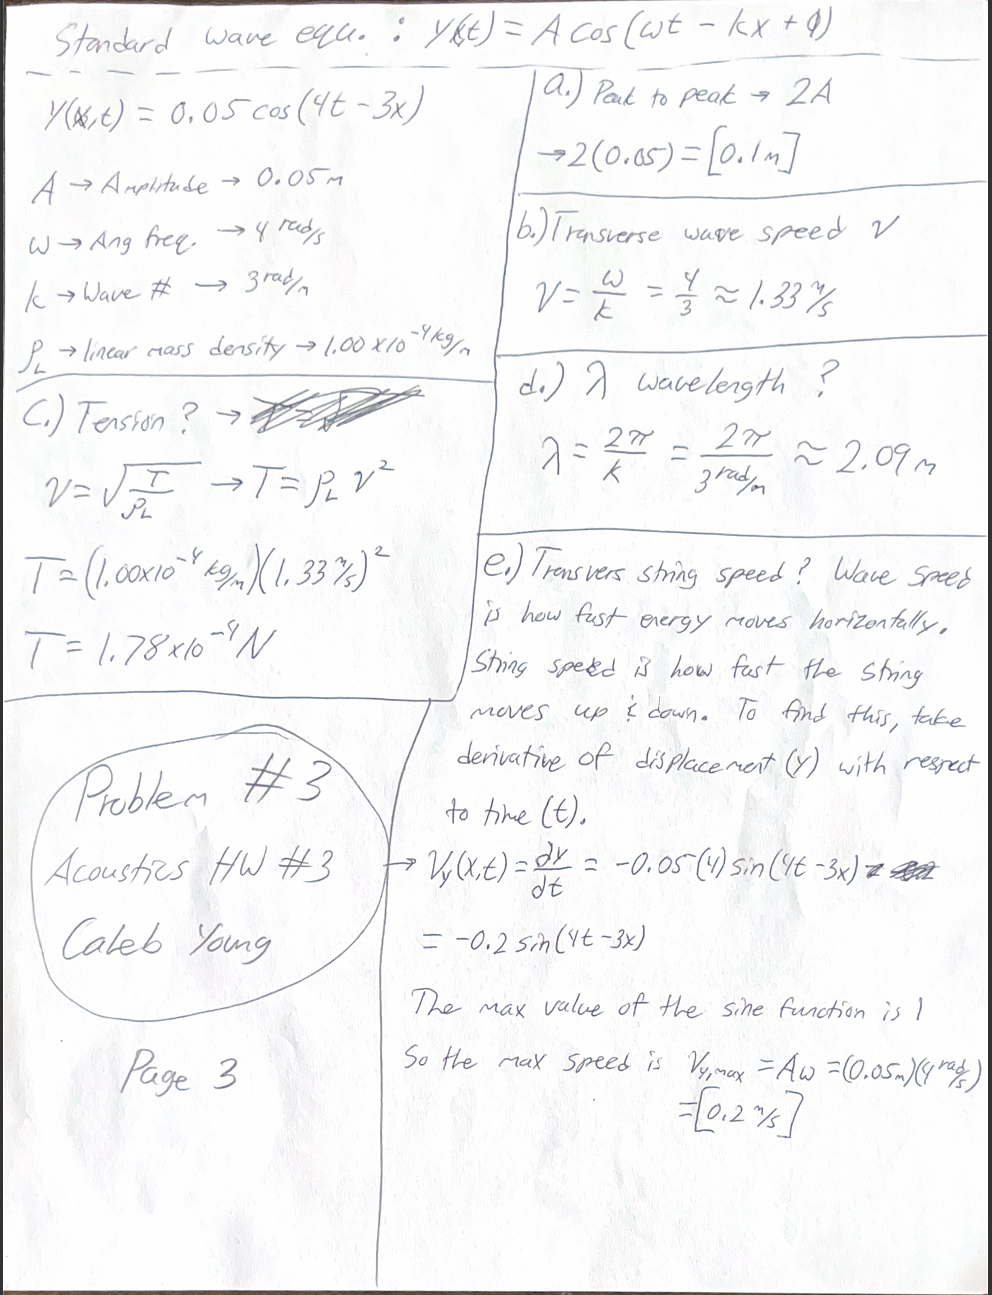

## Problem 4

Plots below

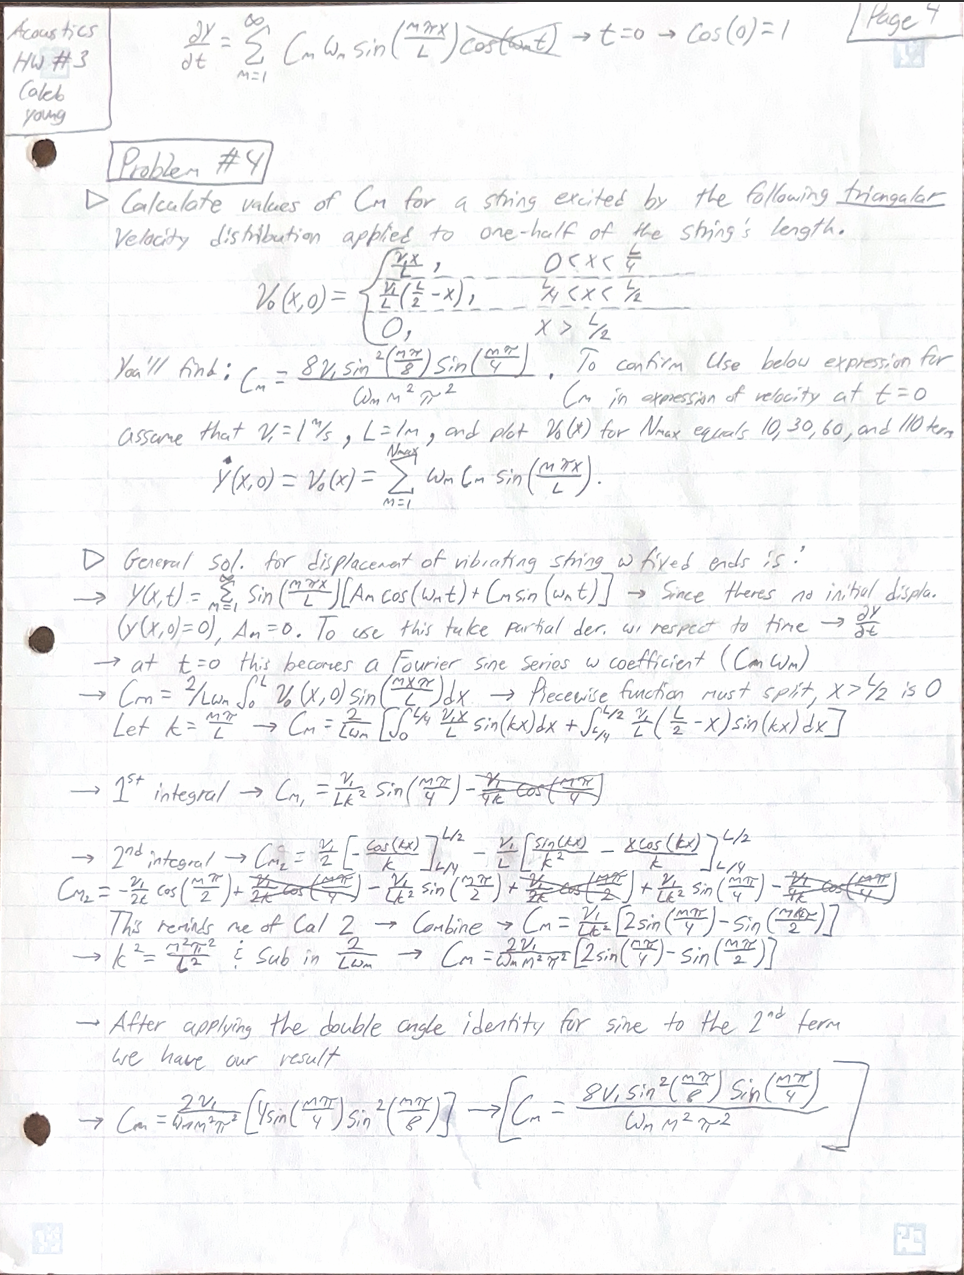

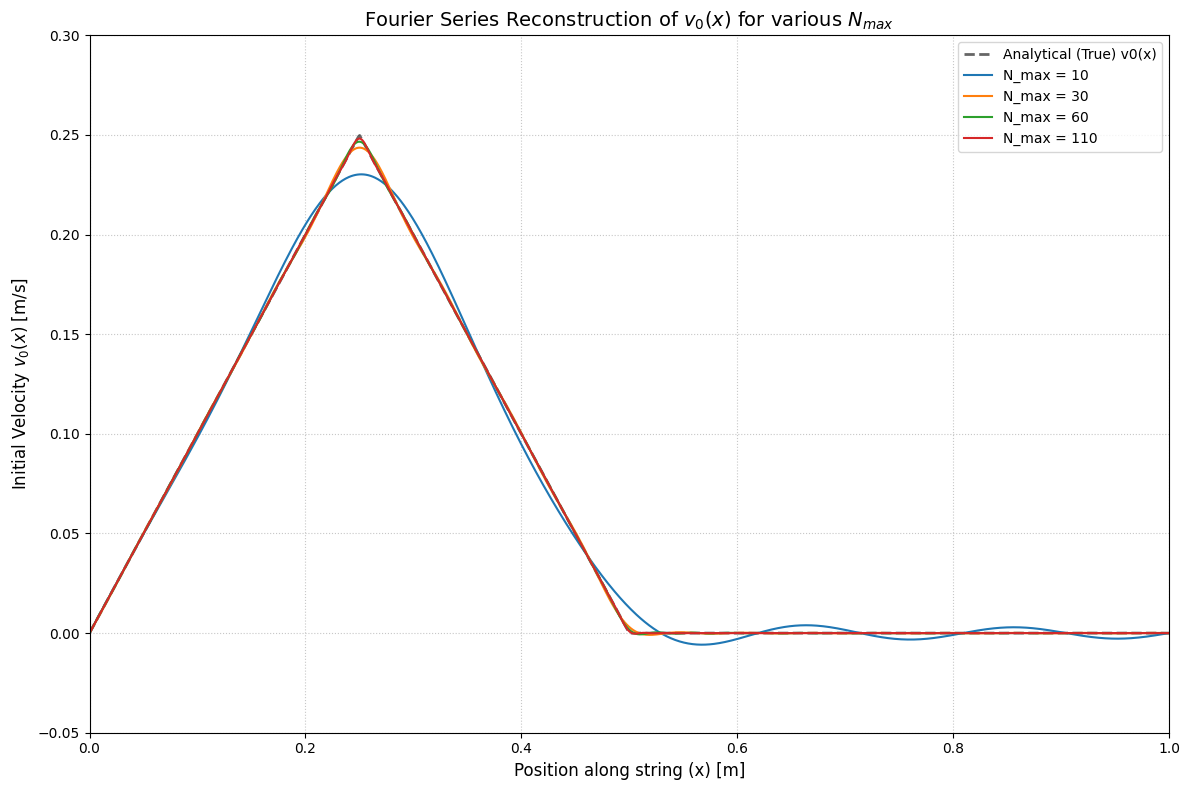

In [5]:
# Plots for Problem 4

import numpy as np
import matplotlib.pyplot as plt

# Given constants
v1 = 1.0  # m/s
L = 1.0   # m
n_max_values = [10, 30, 60, 110]

# Define x range across the whole string
x = np.linspace(0, L, 1000)

# 1. Define the 'True' analytical piecewise function for comparison
def true_v0(x_val):
    if 0 < x_val < L/4:
        return (v1 * x_val) / L
    elif L/4 <= x_val < L/2:
        return (v1 / L) * (L/2 - x_val)
    else:
        return 0

v0_analytical = np.array([true_v0(val) for val in x])

# 2. Setup the plot
plt.figure(figsize=(12, 8))
plt.plot(x, v0_analytical, 'k--', linewidth=2, label='Analytical (True) v0(x)', alpha=0.6)

# 3. Calculate and plot the Fourier Series for each N_max
for N_max in n_max_values:
    v0_reconstructed = np.zeros_like(x)
    
    for m in range(1, N_max + 1):
        # The sum uses omega_m * C_m. 
        # From the problem: omega_m * C_m = [8 * v1 * sin^2(m*pi/8) * sin(m*pi/4)] / (m^2 * pi^2)
        coeff = (8 * v1 * (np.sin(m * np.pi / 8)**2) * np.sin(m * np.pi / 4)) / (m**2 * np.pi**2)
        
        # Add the m-th harmonic to the sum
        v0_reconstructed += coeff * np.sin(m * np.pi * x / L)
        
    plt.plot(x, v0_reconstructed, label=f'N_max = {N_max}')

# Formatting
plt.title(r'Fourier Series Reconstruction of $v_0(x)$ for various $N_{max}$', fontsize=14)
plt.xlabel('Position along string (x) [m]', fontsize=12)
plt.ylabel('Initial Velocity $v_0(x)$ [m/s]', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.xlim(0, L)
plt.ylim(-0.05, 0.3) # Height is v1/4 = 0.25

plt.tight_layout()
plt.show()

## Problem 5 

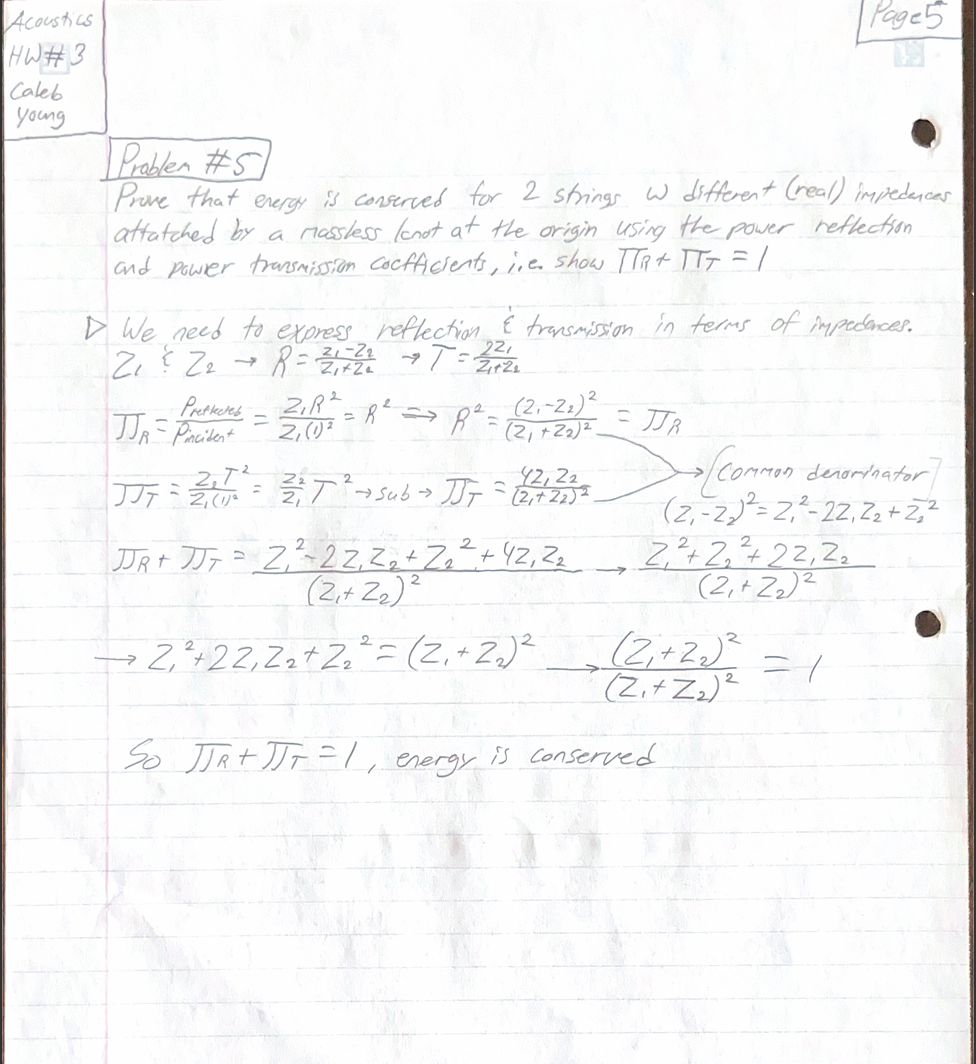